In [1]:
import time
from matplotlib import pyplot as plt

In [4]:
flip_mirror_switch_ni.set_state('Mirror', 'Off')

In [9]:
spectrometer.acquire_spectrum()
while spectrometerlogic._acquisition_running:
    time.sleep(1)
time.sleep(0.1)
spectrometer.save_widget.saveTagLineEdit.setText('def1')
spectrometer.save_spectrum()


In [16]:
scanning_optimize_logic.start_optimize()
while scanning_optimize_logic.module_state()=='locked':
    time.sleep(1) # wait for a long time to 

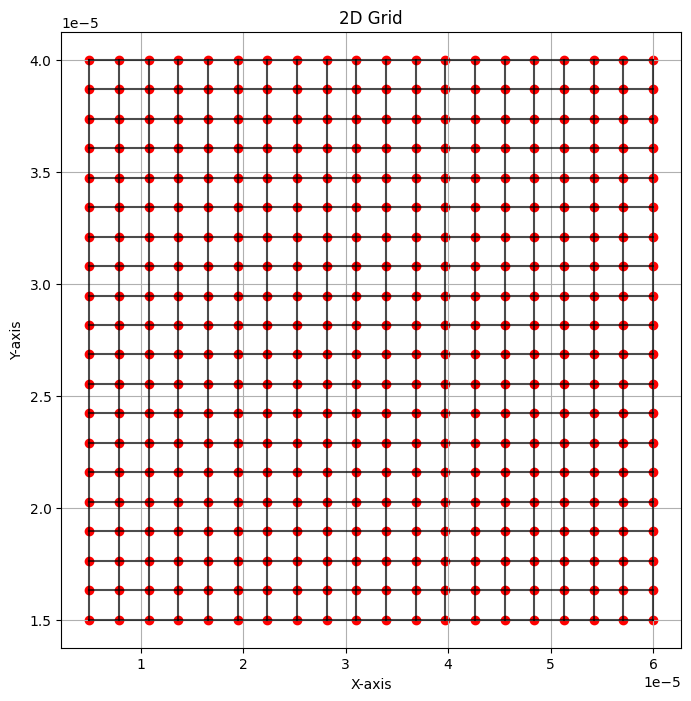

In [2]:
import numpy as np

def create_2d_grid(x_min, x_max, y_min, y_max, x_res, y_res):
    """
    Create a 2D grid within the specified boundaries and resolution.

    Parameters:
    x_min (float): Minimum x boundary.
    x_max (float): Maximum x boundary.
    y_min (float): Minimum y boundary.
    y_max (float): Maximum y boundary.
    x_res (int): Number of points along the x-axis.
    y_res (int): Number of points along the y-axis.

    Returns:
    tuple: Arrays representing the x and y coordinates of the grid.
    """
    x = np.linspace(x_min, x_max, x_res)
    y = np.linspace(y_min, y_max, y_res)
    x_grid, y_grid = np.meshgrid(x, y)
    
    return x_grid, y_grid

# Example usage:
x_min, x_max = 5e-6, 60e-6
y_min, y_max = 15e-6, 40e-6
x_res, y_res = 20, 20

x_grid, y_grid = create_2d_grid(x_min, x_max, y_min, y_max, x_res, y_res)

# Plotting the grid
plt.figure(figsize=(8, 8))
plt.plot(x_grid, y_grid, 'k-', alpha=0.7)  # Plot horizontal lines
plt.plot(x_grid.T, y_grid.T, 'k-', alpha=0.7)  # Plot vertical lines
plt.scatter(x_grid, y_grid, color='red')  # Mark grid points
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('2D Grid')
plt.grid(True)
plt.show()

In [3]:

current_pos = scanning_probe_logic.scanner_target
new_pos = current_pos.copy()

# Flatten the grid arrays for easier iteration
x_flat = x_grid.flatten()
y_flat = y_grid.flatten()

for idx, (x, y) in enumerate(zip(x_flat, y_flat)):
    new_pos['x'] = x
    new_pos['y'] = y
    scanning_probe_logic.set_target_position(
        
            {key: float(value) for key, value in new_pos.items()}
        
    )
    time.sleep(0.2)
    
    scanning_optimize_logic.start_optimize()
    
    # Wait until the module state is no longer 'locked'
    while scanning_optimize_logic.module_state() == 'locked':
        time.sleep(1)
    
    spectrometer.acquire_spectrum()
    
    # Wait until the spectrum acquisition is complete
    while spectrometerlogic._acquisition_running:
        time.sleep(1)
    
    time.sleep(0.1)  # Short delay before saving
    
    # Set the save tag and save the spectrum
    spectrometer.save_widget.saveTagLineEdit.setText(f'def{idx}')
    spectrometer.save_spectrum()


In [ ]:
scanning_probe_logic.set_target_position(
                    current_pos
                )